# Results from the Stage 2 Architecture Search for the Baseline Feed-Forward Neural Network

This notebook loads the architecture search results in CSV format from "ffnn_search/results/arch_search_results_stage2.csv". It sorts the models by their validation MSE and Pearson correlation $\rho$, as only the last one is actually run for the test set, and plots these metrics as barplots for each of the Top 5 models. 

Additionally, here we also elaborate on the parameters used for the architecture search used to train the FFNNs.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
#Set the theme for seaborn
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "figure.dpi": 300
})

In [7]:
# Path to the architecture search results CSV file
results_path = "~/DeepIsoQ/ffnn_search/results/arch_search_results_stage2.csv"
# Load the results into a DataFrame
results_df = pd.read_csv(results_path)
print("Loaded architecture search results:")
print(results_df.head())


Loaded architecture search results:
                 name  hidden        act  dropout  batchnorm     lr momentum  \
0   L1_512_t53_stage2   [512]       tanh      0.0       True  0.003        -   
1  L1_1024_t25_stage2  [1024]  leakyrelu      0.0       True  0.003        -   
2  L1_1024_t41_stage2  [1024]  leakyrelu      0.1       True  0.001        -   
3   L1_1024_t5_stage2  [1024]  leakyrelu      0.1       True  0.002        -   
4  L1_1024_t56_stage2  [1024]       gelu      0.2       True  0.001        -   

  step_size gamma  batch_size  epochs_trained   val_mse  val_pearson  \
0         -     -         128             200  0.843434     0.744078   
1         -     -         256             200  0.843881     0.744401   
2         -     -         128             200  0.859592     0.741751   
3         -     -         192             200  0.857438     0.742168   
4         -     -         128             200  0.841696     0.746201   

   train_time_sec  
0           243.9  
1         

In [8]:
#Sort by validation MSE
df_mse = results_df.sort_values("val_mse", ascending = True)

#Sort by validation Pearson correlation
df_pearson = results_df.sort_values("val_pearson", ascending = False)


/tmp/ipykernel_1474532/2442136500.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1474532/2442136500.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


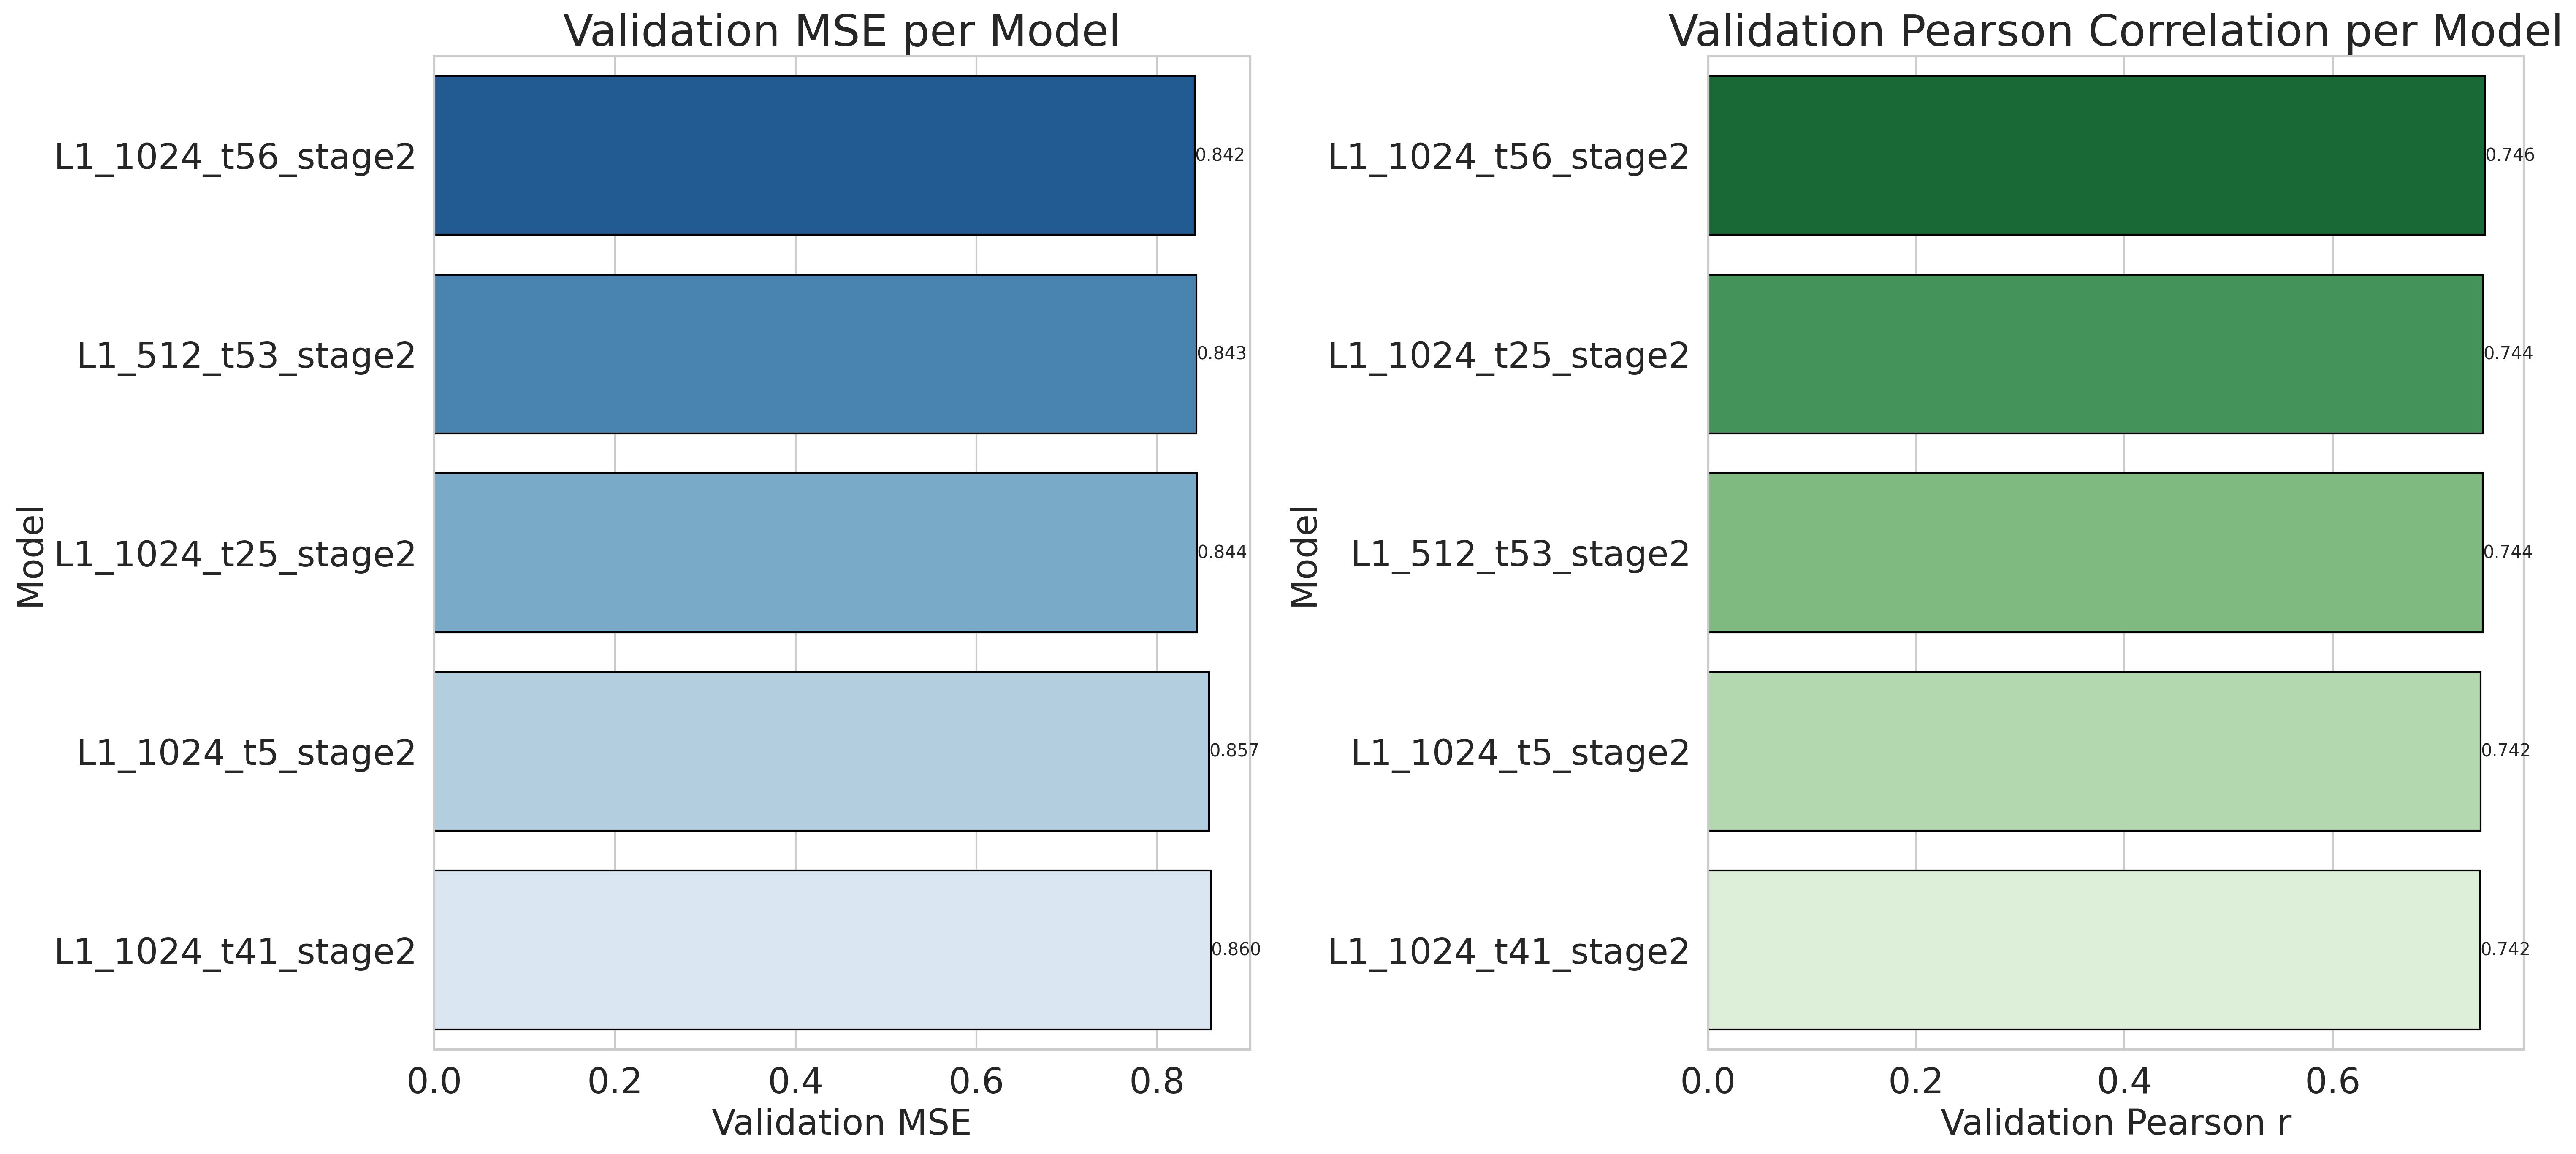

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)

# Validation MSE
sns.barplot(
    ax=axes[0],
    data=df_mse,
    y="name",
    x="val_mse",
    palette="Blues_r",
    edgecolor="black"
)
axes[0].set_title("Validation MSE per Model")
axes[0].set_xlabel("Validation MSE")
axes[0].set_ylabel("Model")
# Annotate bars with MSE values
for i, v in enumerate(df_mse["val_mse"]):
    axes[0].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

# Validation Pearson Correlation
sns.barplot(
    ax=axes[1],
    data=df_pearson,
    y="name",
    x="val_pearson",
    palette="Greens_r",
    edgecolor="black"
)
axes[1].set_title("Validation Pearson Correlation per Model")
axes[1].set_xlabel("Validation Pearson r")
axes[1].set_ylabel("Model")
# Annotate bars with Pearson r values
for i, v in enumerate(df_pearson["val_pearson"]):
    axes[1].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

plt.show()